<div style="background: linear-gradient(135deg, #0f0c29 0%, #302b63 50%, #24243e 100%); padding: 40px 36px; border-radius: 16px; color: white; font-family: 'Segoe UI', sans-serif; border-left: 6px solid #f472b6;">
  <div style="font-size: 12px; color: #f9a8d4; letter-spacing: 3px; text-transform: uppercase; font-weight: 600;">
    SCY1101 — Evaluación Parcial 2 · Notebook 6 de 6
  </div>
  <h1 style="margin: 14px 0 8px; font-size: 32px; font-weight: 700; letter-spacing: -0.5px; color: white;">
    🏆 Análisis Final, Recomendaciones y Defensa
  </h1>
  <p style="color: #fbcfe8; margin: 0 0 24px; font-size: 16px; line-height: 1.6;">
    Todo el proyecto en un notebook. Los resultados, las decisiones, las limitaciones<br>
    y el guion para la defensa individual — con los números reales.
  </p>
  <div style="display: flex; gap: 12px; flex-wrap: wrap;">
    <span style="background: rgba(244,114,182,0.2); color: #f9a8d4; padding: 6px 14px; border-radius: 20px; font-size: 13px; border: 1px solid rgba(244,114,182,0.3);">📊 KPIs finales</span>
    <span style="background: rgba(244,114,182,0.2); color: #f9a8d4; padding: 6px 14px; border-radius: 20px; font-size: 13px; border: 1px solid rgba(244,114,182,0.3);">💼 Recomendaciones</span>
    <span style="background: rgba(244,114,182,0.2); color: #f9a8d4; padding: 6px 14px; border-radius: 20px; font-size: 13px; border: 1px solid rgba(244,114,182,0.3);">✅ Checklist</span>
    <span style="background: rgba(244,114,182,0.2); color: #f9a8d4; padding: 6px 14px; border-radius: 20px; font-size: 13px; border: 1px solid rgba(244,114,182,0.3);">🎤 Guion de defensa</span>
  </div>
  <div style="margin-top: 24px; background: rgba(255,255,255,0.07); border-radius: 10px; padding: 12px 18px; font-size: 13px; color: #f9a8d4;">
    <strong>Progreso del proyecto:</strong>
    <div style="background: rgba(255,255,255,0.15); border-radius: 10px; height: 6px; margin: 8px 0 4px;">
      <div style="background: linear-gradient(90deg, #f472b6, #fb7185); width: 100%; height: 6px; border-radius: 10px;"></div>
    </div>
    <div style="display: flex; justify-content: space-between; font-size: 11px; color: #fbcfe8; opacity: 0.8;">
      <span>✅ EDA</span><span>✅ Modelos</span><span>✅ Evaluación</span><span>✅ Tuning</span><span>✅ Clustering</span><span>▶ Final</span>
    </div>
  </div>
</div>

---

## 🧭 La historia completa del proyecto

<div style="background: #fdf2f8; border-left: 5px solid #ec4899; padding: 20px 24px; border-radius: 0 12px 12px 0; margin: 16px 0; font-family: 'Segoe UI', sans-serif;">
  <strong style="color: #831843; font-size: 15px;">🏆 El camino recorrido</strong><br><br>
  <span style="color: #9d174d; font-size: 14px; line-height: 1.7;">
    Una empresa logística tiene datos reales, con errores reales.
    En lugar de ignorarlos y entrenar modelos directamente, se auditaron primero las cuatro fuentes operativas,
    se documentaron los problemas y se construyeron datasets ML certificados.<br><br>
    Luego se probaron 30 modelos en total (15 por problema), se optimizaron los mejores con dos métodos sistemáticos,
    y se exploró la segmentación natural de los envíos sin etiquetas.<br><br>
    <strong>La idea central para defender:</strong><br>
    Calidad de datos → dataset confiable → modelos comparables → optimización → interpretación → decisiones de negocio.
  </span>
</div>

**Flujo completo del pipeline Kedro:**
```
ingesta → limpieza → transformación → validación → model_input → clustering → entrenamiento → tuning
```
**Resultado:** `Pipeline execution completed successfully. 26/26 tasks.`

In [1]:
from pathlib import Path
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "01_raw"
DATA_MODEL = PROJECT_ROOT / "data" / "05_model_input"
DATA_OUTPUT = PROJECT_ROOT / "data" / "07_model_output"
DATA_REPORT = PROJECT_ROOT / "data" / "08_reporting"
DATA_MODELS = PROJECT_ROOT / "data" / "06_models"

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)


def read_csv(path):
    for enc in ("utf-8", "latin-1"):
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)


def clean_text_columns(df):
    df = df.copy()
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].astype(str).str.replace("Ã³", "o", regex=False)
    return df


---

## 1. 📂 Cargar todos los resultados consolidados

In [2]:
model_input_report = read_csv(DATA_REPORT / "model_input_report.csv")
validation_report = read_csv(DATA_REPORT / "validation_report.csv")
rank_clf = read_csv(DATA_OUTPUT / "ranking_modelos_clasificacion.csv")
rank_reg = read_csv(DATA_OUTPUT / "ranking_modelos_regresion.csv")
metricas_final = read_csv(DATA_OUTPUT / "metricas_modelo_final.csv")
comparacion = read_csv(DATA_OUTPUT / "comparacion_optimizacion.csv")
perfil_clusters = read_csv(DATA_OUTPUT / "perfil_clusters.csv")
metricas_clustering = read_csv(DATA_OUTPUT / "metricas_clustering.csv")

display(metricas_final)


,tipo_problema,modelo_final,etapa,cv_score,criterio_seleccion,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp,mae,mse,rmse,r2
0,clasificacion,11_GaussianNB,grid_search,0.2596,max_f1,0.2356,0.175,0.9655,0.2963,0.5063,13.0,132.0,1.0,28.0,NaN,NaN,NaN,NaN
1,regresion,06_KNeighborsRegressor,grid_search,-1.4432,min_mae,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.4374,2.6246,1.6201,0.1153


---

## 2. 📋 Resumen ejecutivo del proyecto

<div style="background: #fdf2f8; border-left: 5px solid #ec4899; padding: 14px 20px; border-radius: 0 10px 10px 0; margin: 12px 0;">
  <strong>Cuatro bloques, una historia coherente:</strong><br>
  <span style="font-size: 13px; color: #9d174d;">
    Cada bloque del proyecto tiene un resultado concreto con evidencia en archivo.
    La tabla siguiente es el resumen que se puede mostrar en los primeros 2 minutos de la defensa.
  </span>
</div>

In [3]:
resumen = pd.DataFrame([
    {
        "bloque": "Datos",
        "resultado": "Datasets ML sin nulos, sin leakage y sin rangos invalidos",
        "evidencia": "model_input_clasificacion.csv y model_input_regresion.csv"
    },
    {
        "bloque": "Clasificacion",
        "resultado": "Modelo final sensible para detectar incidencias",
        "evidencia": "GaussianNB optimizado con GridSearchCV"
    },
    {
        "bloque": "Regresion",
        "resultado": "Estimacion inicial de dias de transito",
        "evidencia": "KNeighborsRegressor optimizado con GridSearchCV"
    },
    {
        "bloque": "No supervisado",
        "resultado": "Segmentacion exploratoria de operaciones",
        "evidencia": "KMeans, DBSCAN y PCA"
    },
])
resumen


,bloque,resultado,evidencia
0,Datos,"Datasets ML sin nulos, sin leakage y sin rango...",model_input_clasificacion.csv y model_input_re...
1,Clasificacion,Modelo final sensible para detectar incidencias,GaussianNB optimizado con GridSearchCV
2,Regresion,Estimacion inicial de dias de transito,KNeighborsRegressor optimizado con GridSearchCV
3,No supervisado,Segmentacion exploratoria de operaciones,"KMeans, DBSCAN y PCA"


---

## 3. 📊 KPI finales — los números que definen el proyecto

<div style="background: linear-gradient(135deg, #0f2027 0%, #203a43 50%, #2c5364 100%); padding: 24px 28px; border-radius: 12px; color: white; font-family: 'Segoe UI', sans-serif; margin: 16px 0;">
  <h4 style="margin: 0 0 16px; color: #90e0ef;">Los 5 números que debes dominar en la defensa</h4>
  <div style="display: flex; gap: 14px; flex-wrap: wrap;">
    <div style="background: rgba(255,255,255,0.1); border-radius: 10px; padding: 14px 18px; flex: 1; min-width: 120px; text-align: center; border-top: 3px solid #4ade80;">
      <div style="font-size: 24px; font-weight: bold; color: #4ade80;">96.6%</div>
      <div style="font-size: 11px; color: #caf0f8; margin-top: 4px;">Recall clasificación</div>
      <div style="font-size: 10px; color: #90e0ef; margin-top: 2px;">Detecta ~97 de 100 incidencias reales</div>
    </div>
    <div style="background: rgba(255,255,255,0.1); border-radius: 10px; padding: 14px 18px; flex: 1; min-width: 120px; text-align: center; border-top: 3px solid #fbbf24;">
      <div style="font-size: 24px; font-weight: bold; color: #fbbf24;">17.5%</div>
      <div style="font-size: 11px; color: #caf0f8; margin-top: 4px;">Precisión clasificación</div>
      <div style="font-size: 10px; color: #90e0ef; margin-top: 2px;">Genera falsas alarmas → validación humana</div>
    </div>
    <div style="background: rgba(255,255,255,0.1); border-radius: 10px; padding: 14px 18px; flex: 1; min-width: 120px; text-align: center; border-top: 3px solid #60a5fa;">
      <div style="font-size: 24px; font-weight: bold; color: #60a5fa;">29.6%</div>
      <div style="font-size: 11px; color: #caf0f8; margin-top: 4px;">F1 clasificación</div>
      <div style="font-size: 10px; color: #90e0ef; margin-top: 2px;">Balance detección vs falsas alarmas</div>
    </div>
    <div style="background: rgba(255,255,255,0.1); border-radius: 10px; padding: 14px 18px; flex: 1; min-width: 120px; text-align: center; border-top: 3px solid #a78bfa;">
      <div style="font-size: 24px; font-weight: bold; color: #a78bfa;">1.44 días</div>
      <div style="font-size: 11px; color: #caf0f8; margin-top: 4px;">MAE regresión</div>
      <div style="font-size: 10px; color: #90e0ef; margin-top: 2px;">Error promedio estimación de tránsito</div>
    </div>
    <div style="background: rgba(255,255,255,0.1); border-radius: 10px; padding: 14px 18px; flex: 1; min-width: 120px; text-align: center; border-top: 3px solid #f87171;">
      <div style="font-size: 24px; font-weight: bold; color: #f87171;">0.12</div>
      <div style="font-size: 11px; color: #caf0f8; margin-top: 4px;">R² regresión</div>
      <div style="font-size: 10px; color: #90e0ef; margin-top: 2px;">Requiere mejores variables operativas</div>
    </div>
  </div>
</div>

,kpi,valor,interpretacion
0,F1 clasificacion,0.2963,Equilibrio precision/recall para incidencias
1,Recall clasificacion,0.9655,Capacidad de detectar incidencias reales
2,Precision clasificacion,0.1750,Proporcion de alertas correctas
3,MAE regresion,1.4374,Error promedio en dias
4,R2 regresion,0.1153,Poder explicativo del modelo


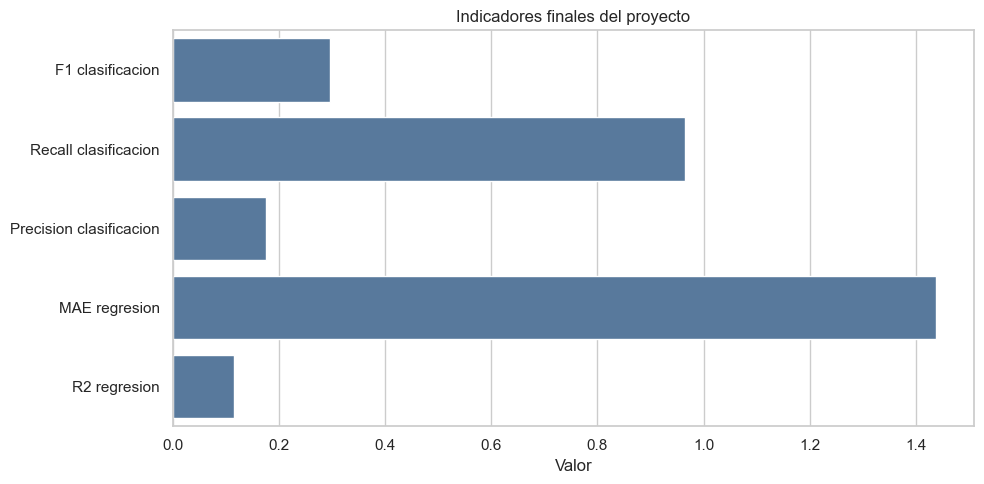

In [4]:
clf_final = metricas_final[metricas_final["tipo_problema"] == "clasificacion"].iloc[0]
reg_final = metricas_final[metricas_final["tipo_problema"] == "regresion"].iloc[0]

kpis = pd.DataFrame([
    {"kpi": "F1 clasificacion", "valor": clf_final["f1"], "interpretacion": "Equilibrio precision/recall para incidencias"},
    {"kpi": "Recall clasificacion", "valor": clf_final["recall"], "interpretacion": "Capacidad de detectar incidencias reales"},
    {"kpi": "Precision clasificacion", "valor": clf_final["precision"], "interpretacion": "Proporcion de alertas correctas"},
    {"kpi": "MAE regresion", "valor": reg_final["mae"], "interpretacion": "Error promedio en dias"},
    {"kpi": "R2 regresion", "valor": reg_final["r2"], "interpretacion": "Poder explicativo del modelo"},
])
display(kpis)

plt.figure(figsize=(10, 5))
sns.barplot(data=kpis, y="kpi", x="valor", color="#4C78A8")
plt.title("Indicadores finales del proyecto")
plt.xlabel("Valor")
plt.ylabel("")
plt.tight_layout()
plt.show()


<div style="background: #fdf2f8; border: 1px solid #fbcfe8; border-radius: 10px; padding: 16px 20px; margin: 8px 0; font-family: 'Segoe UI', sans-serif;">
  <strong style="color: #831843;">💬 Cómo presentar estos KPI en la defensa</strong><br><br>
  <span style="color: #9d174d; font-size: 14px; line-height: 1.7;">
    No presentes los números como si fueran perfectos. Preséntelos como evidencia de un análisis honesto:<br><br>
    <strong>Recall 96.6%</strong> → "El modelo detecta casi todas las incidencias reales — tiene alta sensibilidad."<br>
    <strong>Precisión 17.5%</strong> → "Genera falsas alarmas — se recomienda validación humana antes de actuar."<br>
    <strong>MAE 1.44 días</strong> → "El error promedio es menor de 1.5 días — útil para planificación inicial."<br>
    <strong>R² 0.12</strong> → "El bajo poder explicativo indica que faltan variables como tráfico o clima."<br><br>
    Reconocer límites y proponer mejoras es una defensa más fuerte que inflar métricas.
  </span>
</div>

---

## 4. 🛡️ Calidad de datos: el mensaje que abre la defensa

<div style="background: #fff7ed; border-left: 5px solid #f59e0b; padding: 14px 20px; border-radius: 0 10px 10px 0; margin: 12px 0;">
  <strong>¿Por qué empezar la defensa hablando de calidad de datos?</strong><br>
  <span style="font-size: 13px; color: #78350f;">
    Porque la decisión más importante del proyecto fue NO entrenar sobre <code>master_envios</code>.
    Esa decisión diferencia un análisis superficial de uno riguroso.
    Los errores documentados en el dataset maestro son evidencia de criterio técnico, no de falla.
  </span>
</div>

In [5]:
resumen_validacion = validation_report["estado"].value_counts().rename_axis("estado").reset_index(name="cantidad")
display(resumen_validacion)
display(model_input_report.head(12))


,estado,cantidad
0,ERROR,12
1,ADVERTENCIA,6
2,OK,5


,seccion,item,valor,detalle
0,general,filas_master_original,986,Filas en master_envios antes de preparación ML
1,general,filas_eliminadas_id_nulo,46,Filas con id_envio nulo ? registros no identif...
2,general,filas_excluidas_rangos_modelado,74,Filas excluidas del dataset ML por distancia_k...
3,general,columnas_master_original,61,Columnas en master_envios antes de preparación
4,leakage_eliminado,total_incidencias,EXCLUIDA,Data leakage: 'total_incidencias' contiene inf...
5,leakage_eliminado,costo_impacto_total,EXCLUIDA,Data leakage: 'costo_impacto_total' contiene i...
6,leakage_eliminado,tipos_incidencia,EXCLUIDA,Data leakage: 'tipos_incidencia' contiene info...
7,leakage_eliminado,costo_impacto_total_norm,EXCLUIDA,Data leakage: 'costo_impacto_total_norm' conti...
8,post_evento_clasificacion,fecha_entrega,EXCLUIDA,Post-evento: disponible solo DESPUES del envio...
9,post_evento_clasificacion,dias_en_transito,EXCLUIDA,Post-evento: calculado de fecha_entrega - fech...


<div style="background: #fff7ed; border: 1px solid #fed7aa; border-radius: 10px; padding: 16px 20px; margin: 8px 0; font-family: 'Segoe UI', sans-serif;">
  <strong style="color: #9a3412;">🔐 El argumento central de la defensa</strong><br><br>
  <span style="color: #7c2d12; font-size: 14px; line-height: 1.7;">
    "<code>master_envios</code> tiene 12 errores de validación — rutas y vehículos con IDs que no cruzan entre tablas.
    En lugar de ignorarlo, lo documentamos y creamos datasets ML separados: <strong>866 envíos para clasificación</strong>
    y <strong>790 para regresión</strong>, todos certificados sin nulos, sin leakage y sin rangos inválidos.
    Los modelos no ven los datos problemáticos. Eso es integridad metodológica."
  </span>
</div>

---

## 5. 💼 Recomendaciones de negocio

<div style="background: #f0fdf4; border-left: 5px solid #22c55e; padding: 14px 20px; border-radius: 0 10px 10px 0; margin: 12px 0;">
  <strong>¿Qué hace la empresa con estos resultados?</strong><br>
  <span style="font-size: 13px; color: #14532d;">
    Un análisis sin recomendaciones es incompleto. Cada resultado del proyecto
    se traduce en una acción operativa concreta para el equipo de logística.
  </span>
</div>

In [6]:
recomendaciones = pd.DataFrame([
    {
        "area": "Gestion de riesgo",
        "recomendacion": "Usar el clasificador como semaforo inicial de riesgo operativo.",
        "justificacion": "El recall alto permite detectar gran parte de las incidencias potenciales."
    },
    {
        "area": "Operacion",
        "recomendacion": "Revisar manualmente alertas antes de automatizar decisiones.",
        "justificacion": "La precision es baja y puede generar falsos positivos."
    },
    {
        "area": "Datos",
        "recomendacion": "Mejorar integridad referencial de rutas y vehiculos.",
        "justificacion": "La validacion detecto registros con ids no conectados correctamente."
    },
    {
        "area": "Planificacion",
        "recomendacion": "Agregar variables de trafico, clima, zona, ventanas horarias y demanda.",
        "justificacion": "El R2 bajo en regresion sugiere falta de variables explicativas."
    },
    {
        "area": "Segmentacion",
        "recomendacion": "Usar clusters como vista exploratoria para monitoreo por perfiles.",
        "justificacion": "KMeans entrega grupos descriptivos, aunque la separacion es debil."
    },
])
recomendaciones


,area,recomendacion,justificacion
0,Gestion de riesgo,Usar el clasificador como semaforo inicial de ...,El recall alto permite detectar gran parte de ...
1,Operacion,Revisar manualmente alertas antes de automatiz...,La precision es baja y puede generar falsos po...
2,Datos,Mejorar integridad referencial de rutas y vehi...,La validacion detecto registros con ids no con...
3,Planificacion,"Agregar variables de trafico, clima, zona, ven...",El R2 bajo en regresion sugiere falta de varia...
4,Segmentacion,Usar clusters como vista exploratoria para mon...,"KMeans entrega grupos descriptivos, aunque la ..."


---

## 6. ✅ Checklist de cumplimiento de la rúbrica

In [7]:
checklist = pd.DataFrame([
    ("Kedro run ejecuta", "cumplido"),
    ("Catalogo actualizado", "cumplido"),
    ("Parametros actualizados", "cumplido"),
    ("Datasets ML creados", "cumplido"),
    ("Leakage eliminado", "cumplido"),
    ("15 modelos clasificacion", "cumplido"),
    ("15 modelos regresion", "cumplido"),
    ("Baseline incluido", "cumplido"),
    ("Validacion cruzada", "cumplido"),
    ("RandomizedSearchCV", "cumplido"),
    ("GridSearchCV", "cumplido"),
    ("KMeans", "cumplido"),
    ("DBSCAN", "cumplido"),
    ("PCA", "cumplido"),
    ("Informe/presentacion", "pendiente de redaccion final"),
], columns=["criterio", "estado"])
checklist


,criterio,estado
0,Kedro run ejecuta,cumplido
1,Catalogo actualizado,cumplido
2,Parametros actualizados,cumplido
3,Datasets ML creados,cumplido
4,Leakage eliminado,cumplido
5,15 modelos clasificacion,cumplido
6,15 modelos regresion,cumplido
7,Baseline incluido,cumplido
8,Validacion cruzada,cumplido
9,RandomizedSearchCV,cumplido


---

## 🎤 Guion para la defensa individual

<div style="background: linear-gradient(135deg, #0f0c29 0%, #302b63 50%, #24243e 100%); padding: 28px 32px; border-radius: 12px; color: white; font-family: 'Segoe UI', sans-serif; margin: 16px 0;">
  <h3 style="margin: 0 0 20px; color: #f9a8d4;">🎤 Estructura en 9 puntos — máximo 10 minutos</h3>
  <ol style="color: #fbcfe8; font-size: 14px; line-height: 2; margin: 0; padding-left: 20px;">
    <li>El problema no era solo entrenar modelos: era partir desde datos logísticos con <strong>problemas reales</strong>.</li>
    <li>Kedro ordenó el flujo: ingesta → limpieza → transformación → validación → model_input → modelado.</li>
    <li>No se entrenó sobre <code>master_envios</code> porque tenía <strong>12 errores de validación</strong>.</li>
    <li>Se crearon datasets ML sin nulos, sin leakage y sin rangos inválidos: <strong>866 y 790 envíos</strong>.</li>
    <li>Se probaron <strong>15 modelos de clasificación</strong> y <strong>15 de regresión</strong> con validación cruzada.</li>
    <li>Se optimizaron finalistas con <strong>RandomizedSearchCV</strong> y <strong>GridSearchCV</strong>.</li>
    <li>La clasificación sirve como <strong>alerta temprana sensible</strong> (recall=96.6%), con falsos positivos que requieren validación humana.</li>
    <li>La regresión estima días de tránsito con <strong>MAE=1.44 días</strong>, requiere mejores variables para mayor precisión.</li>
    <li>El clustering identifica <strong>5 segmentos operativos</strong> exploratorios para estrategias diferenciadas.</li>
  </ol>
</div>

<div style="background: #fdf2f8; border: 2px solid #f472b6; border-radius: 12px; padding: 24px 28px; margin: 16px 0; font-family: 'Segoe UI', sans-serif;">
  <strong style="color: #831843; font-size: 15px;">🎯 Ejemplo de cierre oral — memoriza esto</strong><br><br>
  <em style="color: #9d174d; font-size: 14px; line-height: 1.8; display: block;">
    "Mi principal decisión técnica fue no entrenar directamente sobre el dataset maestro,
    porque la validación mostró problemas reales de calidad. Construí datasets específicos para machine learning,
    eliminé leakage y filtré rangos no aptos. Luego comparé 15 modelos de clasificación y 15 de regresión,
    optimicé finalistas con RandomizedSearchCV y GridSearchCV, y complementé con clustering.<br><br>
    Los resultados no son mágicos: el clasificador sirve como alerta temprana con muchos falsos positivos
    y la regresión requiere mejores variables. Pero el flujo es reproducible, honesto
    y conectado con decisiones logísticas."
  </em>
</div>